# Interpretability: what is the classifier actually keying on?

Uses Captum (Integrated Gradients + Saliency) to attribute each prediction back to input tokens, for both:

- **length_controlled** model — the main classifier, pairs truncated to equal length
- **raw** model — trained on uncontrolled lengths, kept to demonstrate the length-shortcut

**Prerequisite**: download the two checkpoint folders trained in `03_finetune_distilbert.ipynb` from Google Drive (`ai_text_detection_checkpoints/{length_controlled,raw}/final/`) into `results/checkpoints/{length_controlled,raw}/final/` locally before running this notebook. Inference-only work like this is fast on CPU — no GPU needed here.

In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / 'src'))

import pandas as pd
from transformers import DistilBertForSequenceClassification

from interpret import get_word_attributions, top_k_tokens
from model import load_tokenizer

CHECKPOINTS_DIR = Path.cwd().parent / 'results' / 'checkpoints'
LENGTH_CONTROLLED_DIR = CHECKPOINTS_DIR / 'length_controlled' / 'final'
RAW_DIR = CHECKPOINTS_DIR / 'raw' / 'final'

for d in (LENGTH_CONTROLLED_DIR, RAW_DIR):
    print(d, '->', 'found' if d.exists() else 'MISSING — download from Colab/Drive first')

d:\Documents\Studies\DeepLearning\results\checkpoints\length_controlled\final -> found
d:\Documents\Studies\DeepLearning\results\checkpoints\raw\final -> found


## Load both checkpoints and a few held-out test examples

Each checkpoint's own `test_split.parquet` (saved during training) is used, so
each model is inspected on the examples it was actually evaluated on.

In [3]:
def load_checkpoint(final_dir):
    tokenizer = load_tokenizer(str(final_dir))
    model = DistilBertForSequenceClassification.from_pretrained(str(final_dir))
    test_df = pd.read_parquet(final_dir / 'test_split.parquet')
    return model, tokenizer, test_df


lc_model, lc_tokenizer, lc_test_df = load_checkpoint(LENGTH_CONTROLLED_DIR)
raw_model, raw_tokenizer, raw_test_df = load_checkpoint(RAW_DIR)

print('length_controlled test set:', lc_test_df.shape)
print('raw test set:', raw_test_df.shape)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

length_controlled test set: (4998, 6)
raw test set: (4998, 6)


## Per-example attributions

Top-attributed tokens (by absolute Integrated Gradients score) for a handful
of correctly-classified human and AI examples from each model.

In [4]:
def show_examples(model, tokenizer, test_df, n_per_label=3, method='ig', seed=0):
    for label, name in [(0, 'HUMAN'), (1, 'AI')]:
        sample = test_df[test_df['label'] == label].sample(n=n_per_label, random_state=seed)
        for _, row in sample.iterrows():
            tokens, scores, pred, prob = get_word_attributions(model, tokenizer, row['text'], method=method)
            correct = 'correct' if pred == label else 'WRONG'
            print(f"\n=== true={name} pred={pred} (p={prob:.2f}, {correct}) ===")
            print('text:', row['text'][:200])
            print('top tokens:', top_k_tokens(tokens, scores, k=8))


print('##### length_controlled model #####')
show_examples(lc_model, lc_tokenizer, lc_test_df)

##### length_controlled model #####

=== true=HUMAN pred=0 (p=1.00, correct) ===
text: More eyes for reading and sifting through laws and documents .
top tokens: [('.', np.float32(0.6421372)), ('more', np.float32(0.4849852)), ('through', np.float32(-0.3781141)), ('and', np.float32(-0.1903036)), ('eyes', np.float32(-0.17876141)), ('##fting', np.float32(0.12134066)), ('reading', np.float32(-0.11836269)), ('documents', np.float32(-0.1075106))]

=== true=HUMAN pred=0 (p=1.00, correct) ===
text: If I give you a quantity of flour , sugar , cinnamon , eggs , and chocolate chips , and take the same quantity of these ingredients for myself , we can both make cookies , but the cookies wo n't come 
top tokens: [('.', np.float32(0.08395021)), ('the', np.float32(-0.0658655)), (',', np.float32(0.048867576)), ('if', np.float32(0.046374943)), (',', np.float32(0.04506393)), ('.', np.float32(0.044011757)), ('a', np.float32(0.043501236)), ('it', np.float32(0.042910308))]

=== true=HUMAN pred=0 (p=1.00, c

In [5]:
print('##### raw (length-uncontrolled) model #####')
show_examples(raw_model, raw_tokenizer, raw_test_df)

##### raw (length-uncontrolled) model #####

=== true=HUMAN pred=0 (p=1.00, correct) ===
text: More eyes for reading and sifting through laws and documents .
top tokens: [('for', np.float32(0.65921617)), ('.', np.float32(0.41484186)), ('more', np.float32(0.3964312)), ('through', np.float32(0.33498266)), ('reading', np.float32(-0.30867457)), ('documents', np.float32(-0.22643702)), ('and', np.float32(0.17886016)), ('laws', np.float32(-0.07056439))]

=== true=HUMAN pred=0 (p=1.00, correct) ===
text: If I give you a quantity of flour , sugar , cinnamon , eggs , and chocolate chips , and take the same quantity of these ingredients for myself , we can both make cookies , but the cookies wo n't come 
top tokens: [('if', np.float32(0.062050518)), ('i', np.float32(0.060753744)), ('was', np.float32(-0.049730852)), ('.', np.float32(0.0484554)), ('is', np.float32(0.04389989)), ('the', np.float32(0.042401247)), (',', np.float32(0.04139851)), (',', np.float32(0.0412995))]

=== true=HUMAN pred=0 (p=1

## Aggregate vocabulary signal

Average attribution per token across many test examples, separately for each
model, to see whether the same words/punctuation show up systematically
(vocabulary/rhythm signal) rather than one-off artifacts.

In [6]:
from collections import defaultdict


def aggregate_token_attributions(model, tokenizer, test_df, n_samples=100, method='ig', seed=0):
    sample = test_df.sample(n=min(n_samples, len(test_df)), random_state=seed)
    sums = defaultdict(float)
    counts = defaultdict(int)
    for _, row in sample.iterrows():
        tokens, scores, _, _ = get_word_attributions(model, tokenizer, row['text'], method=method)
        sign = 1 if row['label'] == 1 else -1  # orient toward "pushes prediction toward AI"
        for tok, score in zip(tokens, scores):
            if tok in ('[CLS]', '[SEP]', '[PAD]'):
                continue
            sums[tok] += sign * score
            counts[tok] += 1
    avg = {tok: sums[tok] / counts[tok] for tok in sums if counts[tok] >= 3}
    return pd.Series(avg).sort_values()


lc_agg = aggregate_token_attributions(lc_model, lc_tokenizer, lc_test_df, n_samples=100)
print('length_controlled — tokens pushing toward HUMAN:')
print(lc_agg.head(15))
print('\nlength_controlled — tokens pushing toward AI:')
print(lc_agg.tail(15))

length_controlled — tokens pushing toward HUMAN:
##mp      -0.118484
she       -0.107310
most      -0.088229
reserve   -0.070577
years     -0.069629
*         -0.057263
;         -0.053635
cash      -0.052348
grow      -0.051134
i         -0.048407
0         -0.045183
last      -0.044046
her       -0.040953
##l       -0.040144
doing     -0.039777
dtype: float32

length_controlled — tokens pushing toward AI:
government    0.161183
reason        0.177564
called        0.178866
piece         0.182271
legal         0.186152
designed      0.220011
known         0.238120
considered    0.245074
especially    0.259471
process       0.280940
why           0.294278
youtube       0.356972
caused        0.366880
reasons       0.492613
\             0.567671
dtype: float32


In [7]:
raw_agg = aggregate_token_attributions(raw_model, raw_tokenizer, raw_test_df, n_samples=100)
print('raw — tokens pushing toward HUMAN:')
print(raw_agg.head(15))
print('\nraw — tokens pushing toward AI:')
print(raw_agg.tail(15))

raw — tokens pushing toward HUMAN:
most         -0.093437
years        -0.090952
here         -0.083903
;            -0.081368
road         -0.052715
him          -0.047015
very         -0.045729
##l          -0.043192
.            -0.041382
##ing        -0.041233
reserve      -0.039743
calculated   -0.036882
un           -0.034783
doing        -0.034069
[            -0.034044
dtype: float32

raw — tokens pushing toward AI:
!              0.111990
okay           0.114993
situations     0.117673
happens        0.119872
pu             0.130689
merchandise    0.130983
potentially    0.144509
imagine        0.147499
overall        0.158554
summary        0.159525
sense          0.166127
helps          0.166415
always         0.176010
simply         0.215997
\              0.237256
dtype: float32


## Quantifying the length shortcut

If a model is exploiting length, its predicted P(AI) should correlate with
raw word count even though word count isn't a linguistic feature. We expect
this correlation to be much weaker for `length_controlled` than for `raw`.

In [8]:
import torch


@torch.no_grad()
def predict_proba_ai(model, tokenizer, texts, max_length=256, batch_size=32):
    probs = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i:i + batch_size])
        enc = tokenizer(batch, truncation=True, padding=True, max_length=max_length, return_tensors='pt')
        logits = model(**enc).logits
        probs.extend(torch.softmax(logits, dim=-1)[:, 1].tolist())
    return probs


def length_shortcut_correlation(model, tokenizer, test_df, n_samples=300, seed=0):
    sample = test_df.sample(n=min(n_samples, len(test_df)), random_state=seed).reset_index(drop=True)
    sample['p_ai'] = predict_proba_ai(model, tokenizer, sample['text'])
    corr = sample['word_count'].corr(sample['p_ai'])
    return corr, sample


lc_corr, lc_sample = length_shortcut_correlation(lc_model, lc_tokenizer, lc_test_df)
raw_corr, raw_sample = length_shortcut_correlation(raw_model, raw_tokenizer, raw_test_df)

print(f'length_controlled: corr(word_count, P(AI)) = {lc_corr:.3f}')
print(f'raw               : corr(word_count, P(AI)) = {raw_corr:.3f}')

length_controlled: corr(word_count, P(AI)) = -0.046
raw               : corr(word_count, P(AI)) = 0.088


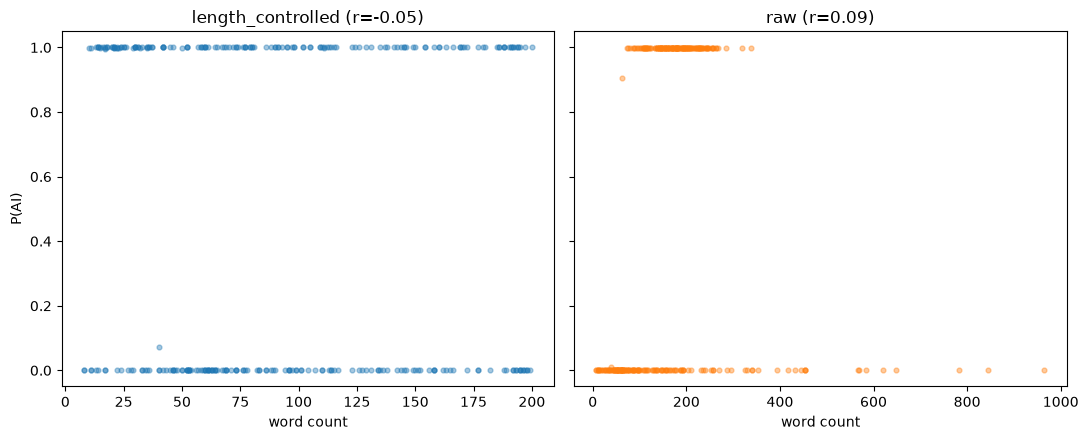

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
axes[0].scatter(lc_sample['word_count'], lc_sample['p_ai'], alpha=0.4, s=12)
axes[0].set_title(f'length_controlled (r={lc_corr:.2f})')
axes[0].set_xlabel('word count')
axes[0].set_ylabel('P(AI)')

axes[1].scatter(raw_sample['word_count'], raw_sample['p_ai'], alpha=0.4, s=12, color='tab:orange')
axes[1].set_title(f'raw (r={raw_corr:.2f})')
axes[1].set_xlabel('word count')

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'results' / 'figures' / 'length_shortcut_correlation.png', dpi=150)
plt.show()